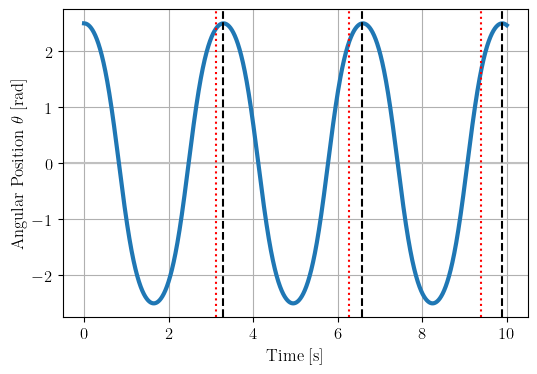

In [1]:
import numpy as np
import matplotlib.pyplot as plt

g, L= 9.8, 1.0 #initial parameters


def Verlet(theta,dt):
    time_vals = [0] 
    theta_vals = [theta] 
    theta_prev = theta - 0.5*(g/L)*np.sin(theta)*dt**2
    for i in range(10000):
        theta_new = 2*theta - theta_prev - (g/L)*np.sin(theta)*dt**2
        theta_prev, theta = theta, theta_new
        theta_vals.append(theta)
        time_vals.append((i+1)*dt)
    return time_vals,theta_vals

def Simpson(theta0,a,b,num_points):
    def function(theta,theta0):
        value = 1 / (np.sqrt(np.cos(theta)-np.cos(theta0)))
        return value
    dx = (b-a)/(num_points)
    integral = function(a,theta0)
    for i in range(1,num_points,2):
        integral += 4 * function(a+(i*dx),theta0)
    for i in range(2,num_points-2,2):
        integral += 2 * function(a+i*dx,theta0)
    integral += function(b,theta0)
    integral *= (dx/3)
    return integral


theta0 = 2.5

theta0 = (theta0 + np.pi) % (2*np.pi) - np.pi # keeps theta bounded to ( -pi, pi ) 
dt = 0.001
integral = np.sqrt(8* L/g)* Simpson(theta0,0,0.999999*theta0,1000000)
times,thetas = Verlet(theta0,dt)
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12
})
plt.figure(figsize=(6,4))
#pi = np.pi
#plt.xticks(np.arange(-4*pi, 4*pi+pi/2, step=pi/2), [r'-4$\pi$', r'-$7\pi/2$',r'-3$\pi$', r'-$5\pi/2$', r'-2$\pi$', r'-$3\pi/2$',r'-$\pi$', r'-$\pi/2$','0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$', r'5$\pi/2$', r'3$\pi$', r'7$\pi/2$', r'4$\pi$'])
plt.xlabel(r"Time [s]")
plt.ylabel(r"Angular Position $\theta$ [rad]")
plt.axhline(y=0,color="silver")
plt.plot(times,thetas,linewidth=3)
plt.grid(True)
plt.axvline(x=np.abs(integral),color="k",ls="--")
plt.axvline(x=2*np.abs(integral),color="k",ls="--")
plt.axvline(x=3*np.abs(integral),color="k",ls="--")
plt.axvline(x=np.sqrt(g/L),color="r",ls=":")
plt.axvline(x=2*np.sqrt(g/L),color="r",ls=":")
plt.axvline(x=3*np.sqrt(g/L),color="r",ls=":")
plt.show()


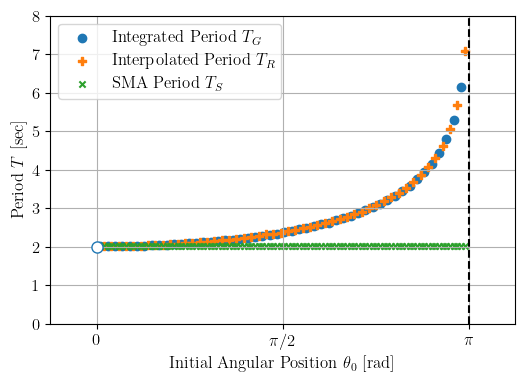

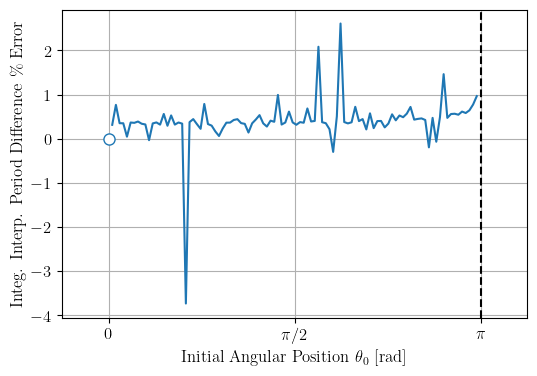

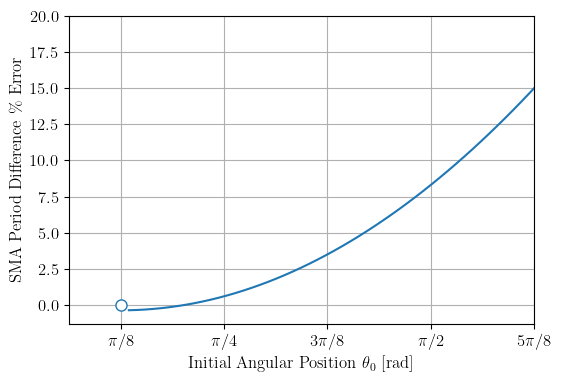

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math

g, L= 9.8, 1.0 #initial parameters

def Verlet(theta,dt):
    time_vals = [0] 
    theta_vals = [theta] 
    theta_prev = theta - 0.5*(g/L)*np.sin(theta)*dt**2
    for i in range(15000):
        theta_new = 2*theta - theta_prev - (g/L)*np.sin(theta)*dt**2
        theta_prev, theta = theta, theta_new
        theta_vals.append(theta)
        time_vals.append((i+1)*dt)
    return time_vals,theta_vals

def Simpson(theta0,a,b,num_points):
    def function(theta,theta0):
        value = 1 / (np.sqrt(np.cos(theta)-np.cos(theta0)))
        return value
    dx = (b-a)/(num_points)
    integral = function(a,theta0)
    for i in range(1,num_points,2):
        integral += 4 * function(a+(i*dx),theta0)
    for i in range(2,num_points-2,2):
        integral += 2 * function(a+i*dx,theta0)
    integral += function(b,theta0)
    integral *= (dx/3)
    return integral

def interpolate(tList,Olist):
    count = 0
    Tlist = []
    for i in range(1,len(Olist)):
        if( math.copysign(1,Olist[i])+math.copysign(1,Olist[i-1])==0):
            tL = ((tList[i]-tList[i-1])/np.abs(Olist[i]+Olist[i-1]))*np.abs(Olist[i-1])+tList[i-1]
            Tlist.append(tL)
            count +=1
            if count == 3:
                period = Tlist[2]-Tlist[0]
                return period

def noSmall(length,g,l):
    x = np.full(length,2*np.pi*np.sqrt(l/g))
    return x

num_thetas = 100
theta_list = np.linspace(0.01*np.pi,0.99*np.pi,num_thetas)

T_integral_list = []
T_interp_list = []

for theta0 in theta_list:
    dt = 0.001
    theta0 = (theta0 + np.pi) % (2*np.pi) - np.pi # keeps theta bounded to ( -pi, pi ) 
    integral = np.sqrt(8* L/g)* Simpson(theta0,0,0.99999*theta0,100000)
    times,thetas = Verlet(theta0,dt)
    interp = interpolate(times,thetas)
    T_integral_list.append(np.abs(integral))
    T_interp_list.append(interp)

#############################################################
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12
})
plt.figure(figsize=(6,4))
#plt.plot(theta_list,T_integral_list,label=r"(-$\pi$,+$\pi$)",linewidth=3)
plt.scatter(theta_list[::2],T_integral_list[::2],label=f"Integrated Period $T_G$")
#plt.plot(theta_list,T_interp_list)
plt.scatter(theta_list[1::2],T_interp_list[1::2],marker="P",label=f"Interpolated Period $T_R$")
nosmall = noSmall(num_thetas,g,L)
plt.scatter(theta_list,nosmall,s=20,marker="x",label = f"SMA Period $T_S$")

plt.plot(0, 2, marker="o",markerfacecolor='white',markeredgecolor='tab:blue',markersize=8)
pi = np.pi
plt.xticks(np.arange(-3*pi/2, 2*pi, step=pi/2), [r'-3$\pi/2$', r'-$\pi$', r'-$\pi/2$', '0', r'$\pi/2$',  r'$\pi$', r'3$\pi/2$'])
plt.ylim(0, 8)
plt.xlim(-np.pi/8,9*np.pi/8)
plt.xlabel(r"Initial Angular Position $\theta_0$ [rad]")
plt.ylabel(r"Period $T$ [sec]")
for item in [-3,-1,1,3]:
    plt.axvline(x=item*np.pi,color="k",ls="--")
plt.legend()
plt.grid(True)
plt.show()
############################################################
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12
})
plt.figure(figsize=(6,4))
percent_error = np.divide((np.array(T_interp_list)-np.array(T_integral_list)),np.array(T_integral_list))*100
plt.plot(theta_list,percent_error)
plt.plot(0, 0, marker="o",markerfacecolor='white',markeredgecolor='tab:blue',markersize=8)

pi = np.pi
plt.xticks(np.arange(-3*pi/2, 2*pi, step=pi/2), [r'-3$\pi/2$', r'-$\pi$', r'-$\pi/2$', '0', r'$\pi/2$',  r'$\pi$', r'3$\pi/2$'])
#plt.ylim(-0.015, 0.025)
plt.xlim(-np.pi/8,9*np.pi/8)
plt.xlabel(r"Initial Angular Position $\theta_0$ [rad]")
plt.ylabel(r"Integ. Interp. Period Difference \% Error")
for item in [-3,-1,1,3]:
    plt.axvline(x=item*np.pi,color="k",ls="--")
plt.grid(True)
plt.show()

############################################################
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.size": 12
})
plt.figure(figsize=(6,4))
SMA_error = np.divide((-np.array(nosmall)+np.array(T_integral_list)), np.array(T_integral_list))*100
plt.plot(theta_list,SMA_error)
plt.plot(0, 0, marker="o",markerfacecolor='white',markeredgecolor='tab:blue',markersize=8)

pi = np.pi
plt.xticks(np.arange(0, 5*pi/8, step=pi/8), [r'$\pi/8$', r'$\pi/4$', r'$3\pi/8$', r'$\pi/2$',r'$5\pi/8$'])
plt.ylim(-1.25, 20)
plt.xlim(-np.pi/16,4*np.pi/8)
plt.xlabel(r"Initial Angular Position $\theta_0$ [rad]")
plt.ylabel(r"SMA Period Difference \% Error")
for item in [-3,-1,1,3]:
    plt.axvline(x=item*np.pi,color="k",ls="--")
plt.grid(True)
plt.show()

In [3]:
import math
theta_prev = 0.01
theta = -0.2
sign_1 = math.copysign(1,theta_prev)
sign_2 = math.copysign(1,theta)
print(sign_1)
print(sign_2)

1.0
-1.0


In [4]:
## Make Period vs Angle comparing the nonSmall and Small angle approximation.
# Then, quantify the threhold where Delta T = some epsilon.
# So, a difference of 1% equated to 0.5 rad or something.